# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.config import load_default_gene_expression_configs

config1, config2 = load_default_gene_expression_configs('distinct')


todo: Loading testing config from replication deconvolution


In [1565]:
from src.gene_expression import read_yl_vst_data_rep
from src.sgd import read_sgd_genes, get_orfname

gene_expression_data = read_yl_vst_data_rep(1)
gene_name = 'PCL1'

def load_gene_expression(gene_name):
    orf_name = get_orfname(gene_name)
    gene_expression = gene_expression_data.loc[orf_name]
    gene_expressions_tpm = pd.read_csv(
        'datasets/yl_cell_cycle/replicate1_gene_expression_TPM.csv')
    gene_expressions_tpm = gene_expressions_tpm.set_index('orf_name')


    gene_expression_tpm = gene_expressions_tpm.loc[orf_name]
    g = np.log2(gene_expression_tpm.values+1)
    return g


In [1609]:
from src.deconvolution_solver import DeconvolutionSolver
g = load_gene_expression('DSE4')
H = config1.H

In [1610]:
from src.expression_gamma_search import GeneExpressionFindOptimalGamma

expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)

	Base error (γ=0):	rn: 1.307314	sn: 1370.815870
	Error boundaries:
		Left:
			Relative (1.05 * e0): 1.37268
			Absolute (e0 + 0.04): 1.34731
			Chosen: 1.347314
		Right:
			Relative (4.0 * e0): 5.22925
			Absolute (e0 + 0.32): 12.3073
			Chosen: 12.307314
	Searching for left boundary gamma...
		γ: 0.0505	rn: 18.9232	sn: 5.7316
		γ: 0.02575	rn: 12.5156	sn: 7.2927
		γ: 0.013375	rn: 10.1543	sn: 8.3580
		γ: 0.0071875	rn: 8.8178	sn: 9.4703
		γ: 0.00409375	rn: 6.4998	sn: 13.0070
		γ: 0.00254688	rn: 5.0799	sn: 16.3939
		γ: 0.00177344	rn: 4.1409	sn: 19.7342
		γ: 0.00138672	rn: 3.8427	sn: 21.1040
		γ: 0.00119336	rn: 3.5002	sn: 23.1259
		γ: 0.00109668	rn: 3.3173	sn: 24.5264
		γ: 0.00104834	rn: 3.2304	sn: 25.2416
		γ: 0.00102417	rn: 3.1851	sn: 25.5866
		γ: 0.00101208	rn: 3.1638	sn: 25.7550
		γ: 0.00100604	rn: 3.1533	sn: 25.8459
		γ: 0.00100302	rn: 3.1480	sn: 25.8921
		γ: 0.00100151	rn: 3.1454	sn: 25.9151
		γ: 0.00100076	rn: 3.1441	sn: 25.9265
	Left boundary gamma found: 0.00100038
	Searching for 

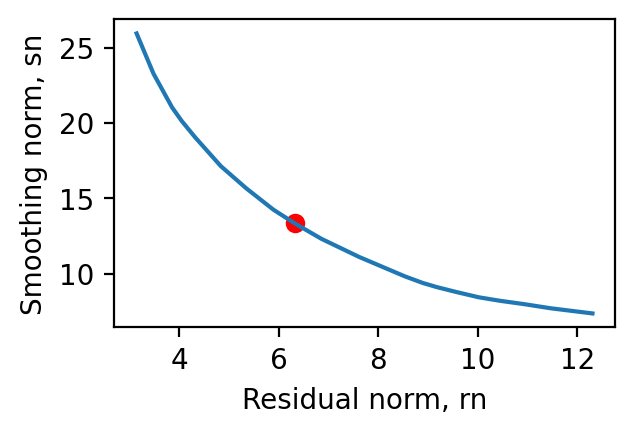

In [1611]:
expression_find_gamma.find_optimal_gamma()

	Base error (γ=0):	rn: 0.014302	sn: 3183.200418
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0150171
			Absolute (e0 + 0.04): 0.054302
			Chosen: 0.015017
		Right:
			Relative (4.0 * e0): 0.057208
			Absolute (e0 + 0.32): 11.0143
			Chosen: 11.014302
	Searching for left boundary gamma...
		γ: 0.0505	rn: 4.2157	sn: 6.7019
		γ: 0.02575	rn: 1.7243	sn: 7.1227
		γ: 0.013375	rn: 0.9123	sn: 7.3899
		γ: 0.0071875	rn: 0.6410	sn: 7.5544
		γ: 0.00409375	rn: 0.5664	sn: 7.6361
		γ: 0.00254688	rn: 0.5405	sn: 7.6649
		γ: 0.00177344	rn: 0.5309	sn: 7.6788
		γ: 0.00138672	rn: 0.5283	sn: 7.6897
		γ: 0.00119336	rn: 0.4856	sn: 7.8363
		γ: 0.00109668	rn: 0.4343	sn: 7.9907
		γ: 0.00104834	rn: 0.4101	sn: 8.0651
		γ: 0.00102417	rn: 0.3984	sn: 8.1016
		γ: 0.00101208	rn: 0.3927	sn: 8.1194
		γ: 0.00100604	rn: 0.3898	sn: 8.1283
		γ: 0.00100302	rn: 0.3884	sn: 8.1328
		γ: 0.00100151	rn: 0.3877	sn: 8.1350
		γ: 0.00100076	rn: 0.3873	sn: 8.1361
	Left boundary gamma found: 0.00100038
	Searching for right bounda

		γ: 0.013375	rn: 2.0465	sn: 6.5344
		γ: 0.0071875	rn: 1.5148	sn: 7.0761
		γ: 0.00409375	rn: 1.2432	sn: 7.5620
		γ: 0.00254688	rn: 1.0676	sn: 8.0520
		γ: 0.00177344	rn: 0.9403	sn: 8.5764
		γ: 0.00138672	rn: 0.8162	sn: 9.2786
		γ: 0.00119336	rn: 0.7818	sn: 9.4854
		γ: 0.00109668	rn: 0.7429	sn: 9.7581
		γ: 0.00104834	rn: 0.7288	sn: 9.8666
		γ: 0.00102417	rn: 0.7232	sn: 9.9105
		γ: 0.00101208	rn: 0.7214	sn: 9.9246
		γ: 0.00100604	rn: 0.7196	sn: 9.9381
		γ: 0.00100302	rn: 0.7183	sn: 9.9487
		γ: 0.00100151	rn: 0.7176	sn: 9.9540
		γ: 0.00100076	rn: 0.7173	sn: 9.9563
	Left boundary gamma found: 0.00100038
	Searching for right boundary gamma...
		γ: 0.0505002	rn: 5.9626	sn: 5.6473
		γ: 0.0752501	rn: 10.6387	sn: 5.1741
		γ: 0.087625	rn: 13.6943	sn: 4.9392
		γ: 0.0814376	rn: 12.1089	sn: 5.0565
		γ: 0.0783438	rn: 11.3593	sn: 5.1153
		γ: 0.076797	rn: 10.9953	sn: 5.1447
		γ: 0.0775704	rn: 11.1764	sn: 5.1300
		γ: 0.0779571	rn: 11.2676	sn: 5.1226
		γ: 0.0777638	rn: 11.2219	sn: 5.1263
		γ: 0.0776671	r

		γ: 0.00101208	rn: 3.5934	sn: 18.8722
		γ: 0.00100604	rn: 3.5842	sn: 18.9385
		γ: 0.00100302	rn: 3.5796	sn: 18.9717
		γ: 0.00100151	rn: 3.5773	sn: 18.9882
		γ: 0.00100076	rn: 3.5762	sn: 18.9965
	Left boundary gamma found: 0.00100038
	Searching for right boundary gamma...
		γ: 0.0505002	rn: 14.7603	sn: 5.2203
		γ: 0.0257503	rn: 9.9499	sn: 6.5196
		γ: 0.0381252	rn: 12.7554	sn: 5.6895
		γ: 0.0443127	rn: 13.8039	sn: 5.4305
		γ: 0.041219	rn: 13.5033	sn: 5.4852
		γ: 0.0396721	rn: 13.1264	sn: 5.5885
		γ: 0.0388987	rn: 12.9246	sn: 5.6451
		γ: 0.038512	rn: 12.8384	sn: 5.6682
		γ: 0.0387053	rn: 12.8786	sn: 5.6580
		γ: 0.0386086	rn: 12.8604	sn: 5.6625
		γ: 0.0385603	rn: 12.8498	sn: 5.6652
		γ: 0.0385845	rn: 12.8552	sn: 5.6638
		γ: 0.0385965	rn: 12.8579	sn: 5.6632
		γ: 0.0385905	rn: 12.8566	sn: 5.6635
		γ: 0.0385935	rn: 12.8572	sn: 5.6633
		γ: 0.038595	rn: 12.8576	sn: 5.6633
		γ: 0.0385943	rn: 12.8574	sn: 5.6633
	Right boundary gamma found: 0.0385939
Finding elbow in the curve, selecting 20 bins 

		γ: 0.087625	rn: 11.9084	sn: 3.7066
		γ: 0.0814376	rn: 10.3758	sn: 3.8166
		γ: 0.0845313	rn: 11.1373	sn: 3.7614
		γ: 0.0829844	rn: 10.7532	sn: 3.7891
		γ: 0.0837579	rn: 10.9447	sn: 3.7753
		γ: 0.0841446	rn: 11.0409	sn: 3.7684
		γ: 0.084338	rn: 11.0886	sn: 3.7649
		γ: 0.0842413	rn: 11.0645	sn: 3.7666
		γ: 0.0841929	rn: 11.0529	sn: 3.7675
		γ: 0.0841688	rn: 11.0469	sn: 3.7679
		γ: 0.0841808	rn: 11.0499	sn: 3.7677
		γ: 0.0841748	rn: 11.0484	sn: 3.7678
		γ: 0.0841778	rn: 11.0492	sn: 3.7678
		γ: 0.0841763	rn: 11.0488	sn: 3.7678
		γ: 0.0841756	rn: 11.0486	sn: 3.7678
	Right boundary gamma found: 0.0841759
Finding elbow in the curve, selecting 20 bins from the left and right boundaries.
		γ: 0.00100038	rn: 0.3146	sn: 5.7110
		γ: 0.00126323	rn: 0.3393	sn: 5.6269
		γ: 0.00159514	rn: 0.3730	sn: 5.5423
		γ: 0.00201426	rn: 0.4339	sn: 5.3939
		γ: 0.0025435	rn: 0.4739	sn: 5.2995
		γ: 0.00321181	rn: 0.5006	sn: 5.2664
		γ: 0.0040557	rn: 0.5431	sn: 5.2230
		γ: 0.00512134	rn: 0.5619	sn: 5.2013
		γ: 0.00

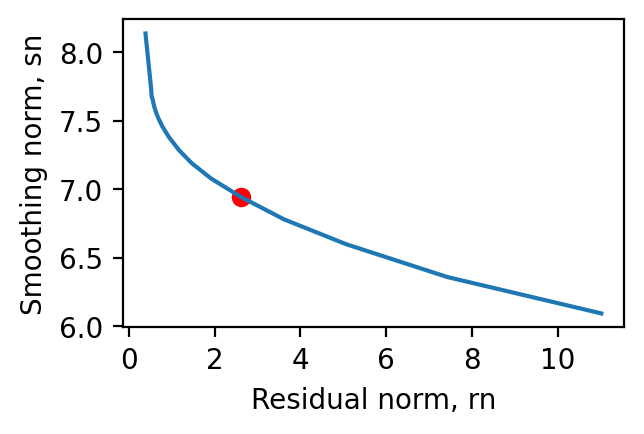

<Figure size 1600x300 with 0 Axes>

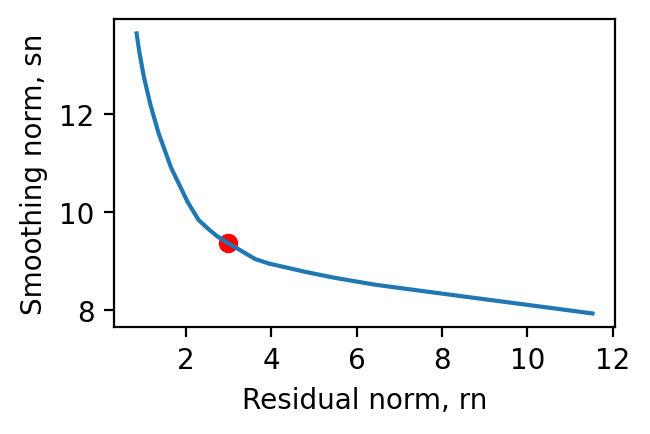

<Figure size 1600x300 with 0 Axes>

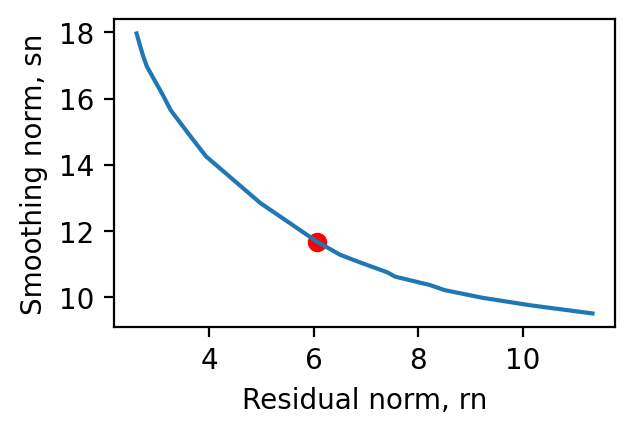

<Figure size 1600x300 with 0 Axes>

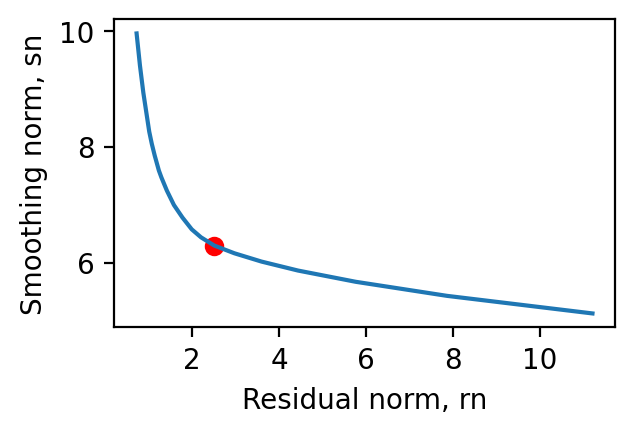

<Figure size 1600x300 with 0 Axes>

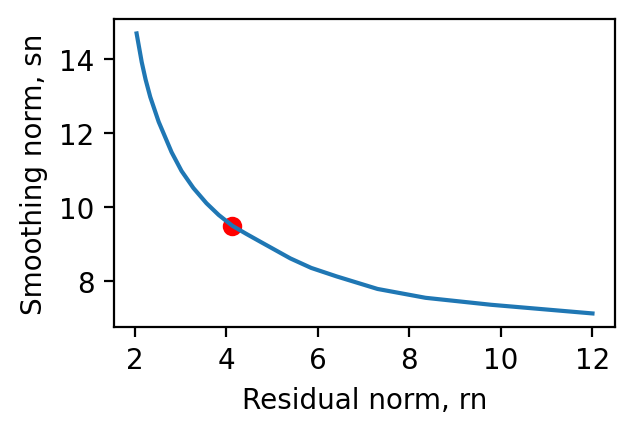

<Figure size 1600x300 with 0 Axes>

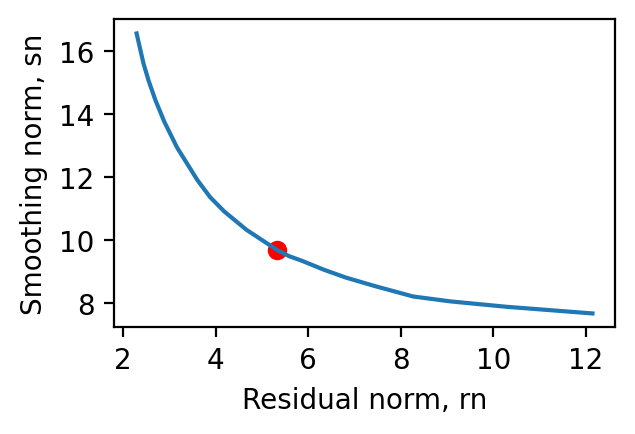

<Figure size 1600x300 with 0 Axes>

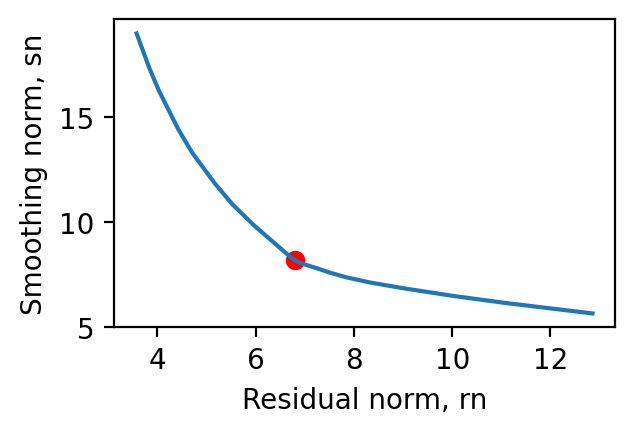

<Figure size 1600x300 with 0 Axes>

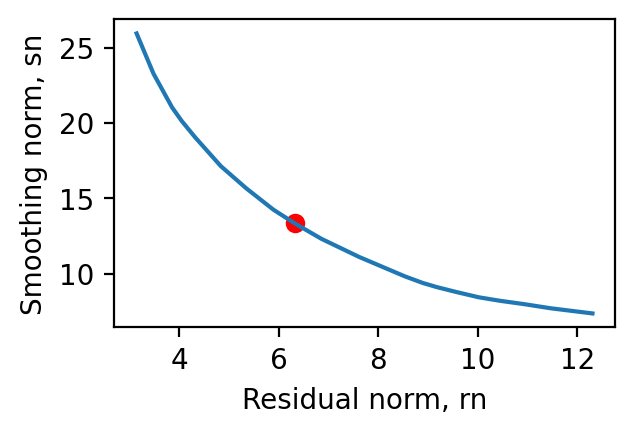

<Figure size 1600x300 with 0 Axes>

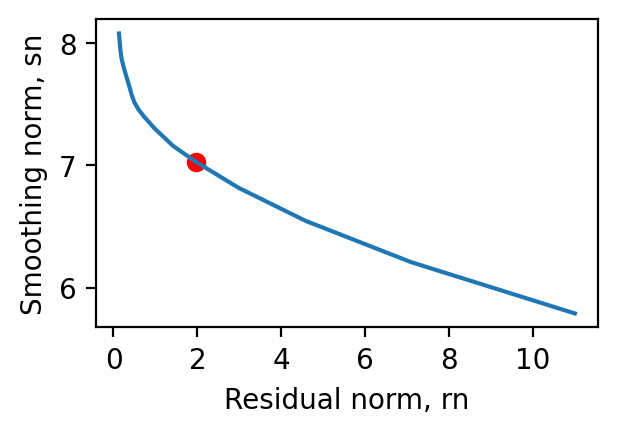

<Figure size 1600x300 with 0 Axes>

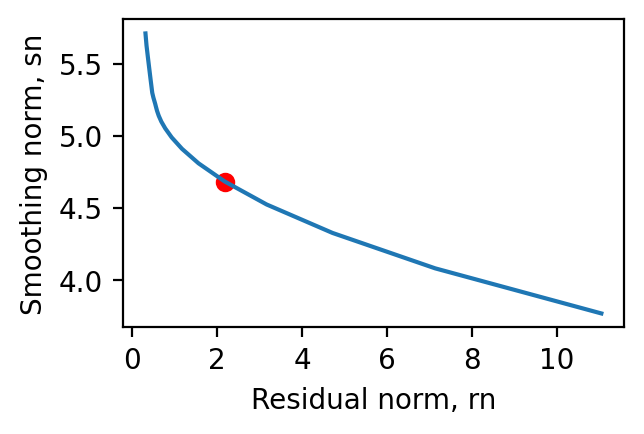

<Figure size 1600x300 with 0 Axes>

In [1618]:

gene_names = ['CLB2','CLN2','PCL1','SIC1','DSE1','DSE2','DSE3','DSE4','MCM6','SSK22']

for gene_name in gene_names:
    
    from src.expression_gamma_search import GeneExpressionFindOptimalGamma
    g = load_gene_expression(gene_name)
    expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                          gamma_min=0.001, gamma_max=0.1)
    expression_find_gamma.find_optimal_gamma()
    plt.savefig(f'output/gamma_sweep_expression/{gene_name}_curve.png')
    plt.cla()
    plt.clf()
    
    expression_find_gamma.plot_gamma_sweep()
    plt.suptitle(gene_name, fontsize=16)
    plt.subplots_adjust(top=0.8)

    plt.savefig(f'output/gamma_sweep_expression/{gene_name}_fit.png')
    plt.cla()
    plt.clf()
